In [9]:
# Functions and dependencies
import numpy as np
from icing_true import ICINGTrue
from icing_model import ICINGModel
from particle_filter import BootstrapParticleFilter
from ext_kalman_filter import ExtendedKalmanFilter
from utils import gen_uex_func, gen_PN_func, gen_D_func, gen_SI_func
rng = np.random.default_rng()

In [10]:
# Basic simulation parameters
sim_hours = 60
dt = 1.0
t = np.arange(0, sim_hours*60+1, dt) #0 to 60 hours with minute-level resolution
y0 = [5.0, 15.0, 15.0, 0.0, 0.0] #Initial conditions: G, I, Q, P1, P2
D_const = 0
SI_const = 2e-4
uex_func = gen_uex_func()
PN_func = gen_PN_func()
D_func = gen_D_func(D_const)
SI_func = gen_SI_func(SI_const)

In [11]:
#  Simulation of true dynamics
gt_model = ICINGTrue()
G_true, I_true, Q_true, P1_true, P2_true = gt_model.simulate(y0, t[0], t[-1], t, uex_func, PN_func, D_func, SI_func)            

In [12]:
# ICING Model Initialization
Ts_meas = 120 # Period in minutes of measurement sampling
t_meas = np.arange(0, sim_hours*60+1, Ts_meas) #0 to 60 hours with minute-level resolution
sample_indices = [np.argmin(np.abs(t - st)) for st in t_meas]
measurement_noise_std = 0.25
G_meas = G_true[sample_indices] + rng.normal(0, measurement_noise_std, size=len(sample_indices))
initial_state = np.append(y0[:3], [gt_model.params['k1']*np.exp(-y0[2]*gt_model.params['k2']/gt_model.params["k3"]), 2e-4])
initial_state = np.expand_dims(initial_state, axis=1)
process_noises = 1e-4/(Ts_meas)*np.ones((len(initial_state),))
process_noises[-1] = (1e-6)**2/(Ts_meas)
input_functions = {"D": D_func, "PN": PN_func, "Uex": uex_func}
model = ICINGModel(params=None,dt=dt, initial_state=initial_state + 0.1*initial_state, process_noise_vars=process_noises, measurement_noise_var=measurement_noise_std**2, u_funcs=input_functions)

In [13]:
# Run Extended Kalman Filter
num_states = len(initial_state)
filter = ExtendedKalmanFilter(num_states=num_states, model=model, Ts_meas=Ts_meas)
sim = filter.simulate(t, t_meas, G_meas, filter)
saved_state, saved_noise_var, G_est, Q_est, I_est, Uen_est, SI_est, G_pred, SI_fit = sim.run()

[  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63.  64.  65.  66.  67.  68.  69.
  70.  71.  72.  73.  74.  75.  76.  77.  78.  79.  80.  81.  82.  83.
  84.  85.  86.  87.  88.  89.  90.  91.  92.  93.  94.  95.  96.  97.
  98.  99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111.
 112. 113. 114. 115. 116. 117. 118. 119. 120.]
[120. 121. 122. 123. 124. 125. 126. 127. 128. 129. 130. 131. 132. 133.
 134. 135. 136. 137. 138. 139. 140. 141. 142. 143. 144. 145. 146. 147.
 148. 149. 150. 151. 152. 153. 154. 155. 156. 157. 158. 159. 160. 161.
 162. 163. 164. 165. 166. 167. 168. 169. 170. 171. 172. 173. 174. 175.
 176. 177. 178. 179. 180. 181. 182. 183. 184. 185. 186. 187. 188. 189.
 190. 191. 192. 193. 194. 195.

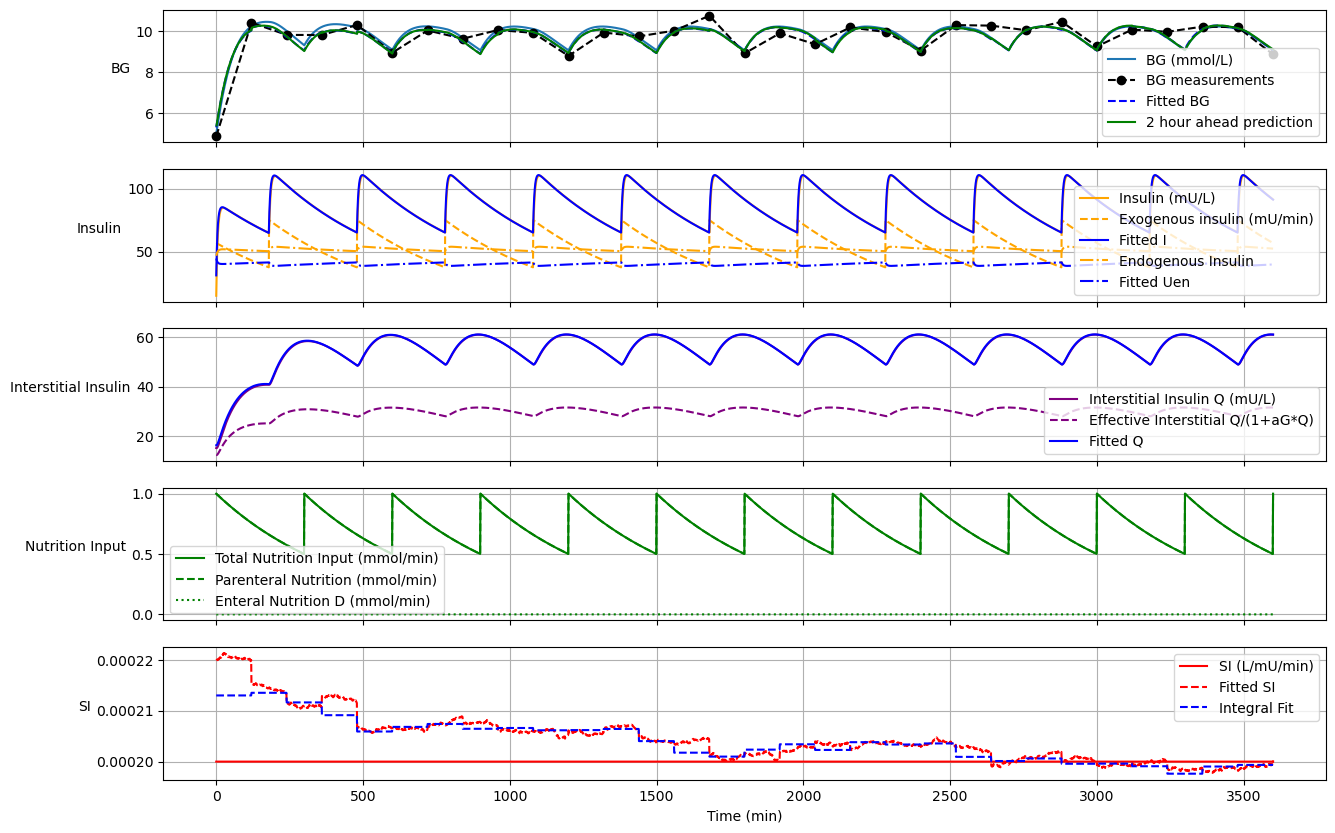

In [14]:
# Plot Extended Kalman Fitler 
sim.plot(saved_state, saved_noise_var, G_est, Q_est, I_est, Uen_est, SI_est, G_pred, SI_fit, I_true, gt_model)

In [15]:
# Run Particle Filter
# num_particles = 500
# filter = BootstrapParticleFilter(num_particles=num_particles, num_states=num_states, model=model, Ts_meas=Ts_meas)
# sim = filter.simulate(t, t_meas, G_meas, filter)
# initial_particles, initial_weights, saved_particles, saved_weights, G_est, Q_est, I_est, Uen_est, SI_est, G_pred = sim.run()

In [16]:
# Plot Particle filter
# ts = [119, 120, 121, 125]
# scale = 1e4
# sim.plot(initial_particles, initial_weights, saved_particles, saved_weights, G_est, Q_est, I_est, Uen_est, SI_est, G_pred, I_true, ts, scale, gt_model)